In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path
import textwrap

# -----------------------------
# 1) Load your CSV
# -----------------------------
file_path = "Post-Test Survey_ User Experience of Collaborative Spatial Decision-Making in AR(1-18).csv"
df = pd.read_csv(file_path, encoding="utf-8-sig")

Saved to C:\Users\PeggyTsai\Desktop\Python\250724_experiment\likert_diverging_neutral_split6.png


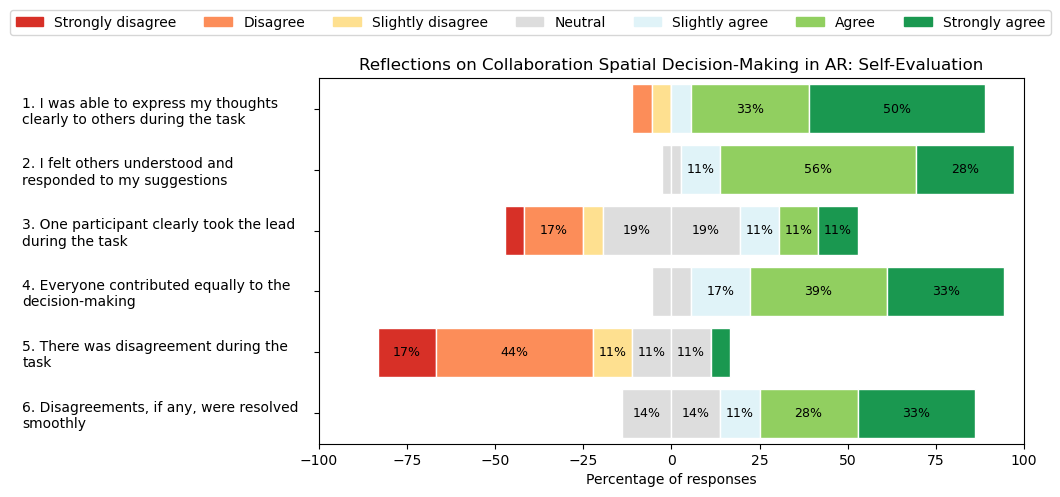

In [5]:
# -----------------------------
# 2) Normalise responses to the 7 fixed labels
# -----------------------------
scale = [
    "strongly disagree",
    "disagree",
    "slightly disagree",
    "neutral",
    "slightly agree",
    "agree",
    "strongly agree",
]

def norm(x: object) -> str | None:
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    # map short variants if they appear
    aliases = {
        "strongly agree": "strongly agree",
        "agree": "agree",
        "slightly agree": "slightly agree",
        "neutral": "neutral",
        "slightly disagree": "slightly disagree",
        "disagree": "disagree",
        "strongly disagree": "strongly disagree",
        "sa": "strongly agree",
        "a": "agree",
        "sla": "slightly agree",
        "n": "neutral",
        "sld": "slightly disagree",
        "d": "disagree",
        "sd": "strongly disagree",
        "7": "strongly agree",
        "6": "agree",
        "5": "slightly agree",
        "4": "neutral",
        "3": "slightly disagree",
        "2": "disagree",
        "1": "strongly disagree",
    }
    return aliases.get(s, None)

# -----------------------------
# 3) Detect Likert question columns
# -----------------------------
# candidate_cols = []
# for col in df.columns:
#     # skip obvious non-Likert columns
#     if re.search(r"(id|name|email|comments?|advantage|easier|aspects|challenges)", col, re.I):
#         continue
#     vals = df[col].dropna().astype(str).str.lower().unique().tolist()
#     if any(v in " ".join(vals) for v in ["agree", "disagree", "neutral"]):
#         candidate_cols.append(col)

# If you want to manually control which questions are plotted, uncomment and edit:
candidate_cols = [
    # "1. I was able to quickly access the system and begin using it without difficulty.",
    # "2. The system helped me complete the intended task successfully.",
    # "3. I was able to perform actions within the system with minimal effort.",
    # "4. I felt I could interact with the environment and digital elements easily.",
    # "5. I always knew where I was and how to reach my intended location.",
    # "6. The system was useful in helping me make spatial decisions.",
    # "7. Overall, I found the system easy to use."
    # "1. I understood how to use the system immediately without needing additional instructions",
    # "2. Information was presented in a way that was easy to process and not overwhelming.",
    # "3. After a short time away, I would still remember how to use this system."
    # "1. I felt like I was interacting with others, not just the system",
    # "2. I was aware of where other participants were and what they were doing.",
    # "3. Using this system helped me feel I was contributing meaningfully to the group task",
    # "4. This experience made me feel more aware of my own role and decision-making within a group",
    # "5. I would be willing to use this system again in a future collaborative task."
    # "1. I felt I had enough freedom to make my own decisions in this shared space",
    # "2. I felt connected to the other participants during the task",
    # "3. The digital content felt like a natural part of the physical environment",
    # "4. I could understand why other participants made certain decisions"
    # "1. I chose the location based on its visibility within the environment",
    # "2. I selected a location that seemed central or easy to reach",
    # "3. I tried to avoid locations that might block others’ view or access",
    # "4. I made my choice based on personal preference, regardless of others"
    "1. I was able to express my thoughts clearly to others during the task",
    "2. I felt others understood and responded to my suggestions",
    "3. One participant clearly took the lead during the task",
    "4. Everyone contributed equally to the decision-making",
    "5. There was disagreement during the task",
    "6. Disagreements, if any, were resolved smoothly"




]

if not candidate_cols:
    raise RuntimeError("No Likert question columns detected. Specify columns manually if needed.")

# Keep order as in the CSV
likert = df[candidate_cols].copy()
for c in candidate_cols:
    likert[c] = likert[c].map(norm)

# -----------------------------
# 4) Compute % per category (rows = questions, cols = 7 bins)
#    Neutral is later split half-left / half-right
# -----------------------------
counts = []
for c in candidate_cols:
    vc = likert[c].value_counts(dropna=True)
    row = [vc.get(label, 0) for label in scale]
    total = sum(row) if sum(row) > 0 else 1
    counts.append([x / total * 100.0 for x in row])
counts = np.array(counts)  # shape: (n_questions, 7)

# -----------------------------
# 5) Build diverging positions (neutral split)
#    Left side: (1..3) + 0.5*neutral
#    Right side: (5..7) + 0.5*neutral
# -----------------------------
neg = counts[:, 0:3]                     # 1..3
neu = counts[:, 3] / 2.0                # half to left, half to right
pos = counts[:, 4:7]                     # 5..7

nq = counts.shape[0]
y = np.arange(nq)

# Colors (red -> grey -> green)
colors = [
    "#d73027",  # strongly disagree
    "#fc8d59",  # disagree
    "#fee090",  # slightly disagree
    "#dddddd",  # neutral (we will plot twice, half on each side)
    "#e0f3f8",  # slightly agree
    "#91cf60",  # agree
    "#1a9850",  # strongly agree
]

fig_h = max(3.5, 0.6 * nq + 1.5)
plt.figure(figsize=(12, fig_h))

# --- draw left side ---
left_start = - (neg.sum(axis=1) + neu)  # total width on left
# segment 1: strongly disagree
w = neg[:, 0]
plt.barh(y, w, left=left_start, color=colors[0], edgecolor="white")
# segment 2: disagree
left_2 = left_start + neg[:, 0]
w = neg[:, 1]
plt.barh(y, w, left=left_2, color=colors[1], edgecolor="white")
# segment 3: slightly disagree
left_3 = left_2 + neg[:, 1]
w = neg[:, 2]
plt.barh(y, w, left=left_3, color=colors[2], edgecolor="white")
# neutral (left half)
left_neu = left_3 + neg[:, 2]
w = neu
plt.barh(y, w, left=left_neu, color=colors[3], edgecolor="white")

# --- draw right side ---
right_start = 0.0
# neutral (right half)
w = neu
plt.barh(y, w, left=right_start, color=colors[3], edgecolor="white")
# slightly agree
right_2 = right_start + neu
w = pos[:, 0]
plt.barh(y, w, left=right_2, color=colors[4], edgecolor="white")
# agree
right_3 = right_2 + pos[:, 0]
w = pos[:, 1]
plt.barh(y, w, left=right_3, color=colors[5], edgecolor="white")
# strongly agree
right_4 = right_3 + pos[:, 1]
w = pos[:, 2]
plt.barh(y, w, left=right_4, color=colors[6], edgecolor="white")

# --- add % labels (only if wide enough to avoid clutter) ---
def add_labels(widths, lefts, label):
    for i in range(nq):
        w = widths[i]
        if w >= 6:  # threshold for readability
            x = lefts[i] + w / 2.0
            plt.text(x, y[i], f"{w:.0f}%", va="center", ha="center", fontsize=9)

add_labels(neg[:,0], left_start, "sd")
add_labels(neg[:,1], left_2, "d")
add_labels(neg[:,2], left_3, "sld")
add_labels(neu, left_neu, "neuL")

add_labels(neu, np.zeros(nq), "neuR")
add_labels(pos[:,0], right_2, "sla")
add_labels(pos[:,1], right_3, "a")
add_labels(pos[:,2], right_4, "sa")

# -----------------------------
# 6) Cosmetics
# -----------------------------

wrapped_labels = [textwrap.fill(q, width=40) for q in candidate_cols]
ax = plt.gca()
ax.set_yticks(y)
ax.set_yticklabels(wrapped_labels, ha="left")
ax.tick_params(axis="y", pad=210)  # 大 pad 讓文字整塊往外推
ax.set_ylim(nq - 0.5, -0.5)
plt.subplots_adjust(left=0.42)    # 增加左邊界，避免被裁切


plt.xlabel("Percentage of responses")
figureTitle = "Reflections on Collaboration Spatial Decision-Making in AR: Self-Evaluation"
plt.title(figureTitle)
plt.xlim(-100, 100)

# build legend handles in the correct order
from matplotlib.patches import Patch
legend_handles = [
    Patch(color=colors[0], label="Strongly disagree"),
    Patch(color=colors[1], label="Disagree"),
    Patch(color=colors[2], label="Slightly disagree"),
    Patch(color=colors[3], label="Neutral"),
    Patch(color=colors[4], label="Slightly agree"),
    Patch(color=colors[5], label="Agree"),
    Patch(color=colors[6], label="Strongly agree"),
]
plt.legend(handles=legend_handles, loc="lower center", ncol=7, bbox_to_anchor=(0.3, 1.10))

plt.tight_layout()
out = Path("likert_diverging_neutral_split6.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
print(f"Saved to {out.resolve()}")
plt.show()


In [16]:
# 定義 Likert scale 七個合法選項
valid_scale = {
    "strongly disagree": 1,
    "disagree": 2,
    "slightly disagree": 3,
    "neutral": 4,
    "slightly agree": 5,
    "agree": 6,
    "strongly agree": 7,
}

# 1) 找出 Likert 題目欄位（完全屬於七個選項的）
likert_cols = []
for col in df.columns:
    unique_vals = (
        df[col].dropna()
        .astype(str)
        .str.strip()
        .str.lower()
        .unique()
    )
    if all(val in valid_scale for val in unique_vals):
        likert_cols.append(col)


# 2) 建立只包含這些 Likert 題目的 DataFrame
likert_df = df[likert_cols].applymap(
    lambda x: valid_scale.get(str(x).strip().lower(), np.nan)
)

# 3) 計算平均分數 (1~7)
avg_scores = likert_df.mean()

# 顯示結果
avg_scores


C:\Users\PeggyTsai\AppData\Local\Temp\ipykernel_26736\127499967.py:27: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  likert_df = df[likert_cols].applymap(


1. I was able to quickly access the system and begin using it without difficulty.                                                    4.611111
2. The system helped me complete the intended task successfully.                                                                     5.055556
3. I was able to perform actions within the system with minimal effort.                                                              4.166667
4. I felt I could interact with the environment and digital elements easily.                                                         4.333333
5. I always knew where I was and how to reach my intended location.                                                                  5.611111
6. The system was useful in helping me make spatial decisions.                                                                       5.055556
7. Overall, I found the system easy to use.                                                                                          4.444444
1. I u